In [1]:
import numpy as np
import os
import time
import math
import math
import random


In [144]:
def create_volume(outliers):
    true_mean = np.zeros((64, 64))
    true_std = np.zeros((64, 64))
    volume = np.zeros((5000, 64, 64))
    np.random.seed(1)
    for i in range(64):
        for j in range(64):
            #create 5000 value normally distributed and add to a pixel
            s = np.random.normal(1, 1, 5000)
            #volume[i][j][k] = s
            for k in range(5000):
                
                volume[k][i][j] = s[k]
        
            #Capture true mean and std to use for later
            true_mean[i][j] = np.mean(s)
            true_std[i][j] = np.std(s)
            
            #Add Outliers at random indicies
            indicies = np.random.randint(0, 4999, outliers)
            for o in range(outliers):
                g = indicies[o]
                outs = np.random.uniform(4, 11)
                volume[g][i][j] = outs
                
    return volume, true_mean, true_std

In [2]:
np.shape(volume) #This is the shape of the volume that I have been using

(5000, 64, 64)

In [145]:
def algorithm(data, t):
    
    # Initialize variables for running stats
    n = 0      # Count of valid values
    mean = 0   # Running mean
    M2 = 0     # Sum of squares of differences from the current mean
    threshold = t  # Number of standard deviations to trim outliers

    # Loop through each value in the stream
    for value in data:
        # Outlier detection: only skip trimming for the first value
        if n > 5:
            # Calculate temporary standard deviation
            variance = M2 / (n - 1) if n > 1 else 0
            stddev = math.sqrt(variance)

            # Check if value is within threshold * stddev from the mean
            if abs(value - mean) > threshold * stddev:
                #print(f"Value {value} is considered an outlier and will be skipped.")
                continue

        # Update running statistics for non-outliers
        n += 1
        delta = value - mean
        mean += delta / n
        delta2 = value - mean
        M2 += delta * delta2


    return mean, stddev

The code above is for a 1D array, while the code below can be used for our volume

In [4]:
#Same algorithm but for images, can adjust threshold and buffers
def image_algorithm(volume, t, b):
    count_image = np.zeros((64, 64))
    mean_image = np.zeros((64, 64))
    sum_squared_image = np.zeros((64, 64))
    threshold = t
    buffer_size = b
    for i in range(5000):
        for j in range(64):
            for k in range(64):
                n = count_image[j][k]      # Count of valid values
                mean = mean_image[j][k]   # Running mean
                M2 = sum_squared_image[j][k]
                value = volume[i][j][k]
                
                if n > buffer_size:     
                    # Calculate temporary standard deviation
                    variance = M2  / (n - 1) if n > 1 else 0
                    stddev = math.sqrt(variance)

                    # Check if value is within threshold * stddev from the mean
                    if abs(value - mean) > threshold * stddev:
                        #print(f"Value {value} is considered an outlier and will be skipped.")
                        continue

                # Update running statistics for non-outliers
                n += 1
                delta = value - mean
                mean += delta / n
                delta2 = value - mean
                M2 += delta * delta2

                    
                    #Update Values
                count_image[j][k] = n     # Count of valid values
                mean_image[j][k] = mean  # Running mean
                sum_squared_image[j][k] = M2
            
    std_image =  np.sqrt(sum_squared_image  / (count_image - 1))
    return mean_image, std_image


        


In [146]:

final = dict()
for buffer_size in range(1, 10, 1):
    percent_mean_errors = []
    percent_std_errors = []
    volume, true_mean, true_std = create_volume(500)
    mean, std = image_algorithm(volume, 3, buffer_size)
    diff_in_means = mean - true_mean
    diff_in_std = std - true_std
    percent_mean_errors.append(abs(diff_in_means/true_mean) * 100)
    percent_std_errors.append(abs(diff_in_std/ true_std) * 100)
    vals = 0
    outliers_mean = 0
    outliers_std = 0
    re_mean = np.reshape(percent_mean_errors, (4096))
    re_std = np.reshape(percent_std_errors, (4096))

    for i in range(len(re_mean)):
        if(re_mean[i] > 10):
            outliers_mean +=1
        if(re_std[i] > 10):
            outliers_std +=1
            

    final[buffer_size] = (np.mean(percent_mean_errors), np.mean(percent_std_errors), outliers_mean, outliers_std, np.max(percent_mean_errors), np.max(percent_std_errors))

    
    


In [147]:
final #this outputs the different percent errors, as well as the number of pixels that have extremeley high perecnet erros, as well as the highest percent error

{1: (1.6614319797536314,
  2.8569328441589725,
  52,
  141,
  718.0527261371428,
  271.72908502159163),
 2: (1.07102987243288,
  2.3513725435160024,
  28,
  139,
  29.055329703812966,
  43.94348779417757),
 3: (1.1754465843711241,
  2.466632896074808,
  35,
  160,
  22.007271616419185,
  43.94348779417757),
 4: (1.286960526965975,
  2.594616519544579,
  39,
  188,
  22.007271616419185,
  43.94348779417757),
 5: (1.3866727784286645,
  2.722571061654836,
  44,
  210,
  22.007271616419185,
  43.94348779417757),
 6: (1.479140585204469,
  2.8296062738502377,
  48,
  224,
  22.546345620599787,
  47.12401226680946),
 7: (1.565095694776303,
  2.9307812777689386,
  52,
  241,
  22.546345620599787,
  47.12401226680946),
 8: (1.6663121310462086,
  3.06491902197316,
  57,
  264,
  22.546345620599787,
  47.12401226680946),
 9: (1.7614273617523235,
  3.196926072140312,
  61,
  284,
  22.546345620599787,
  47.12401226680946)}

The code above shows that the same pixel is causing trouble for buffer sizes of 2, 3, 4, and 5 as the max percent error remains the same for these iterations

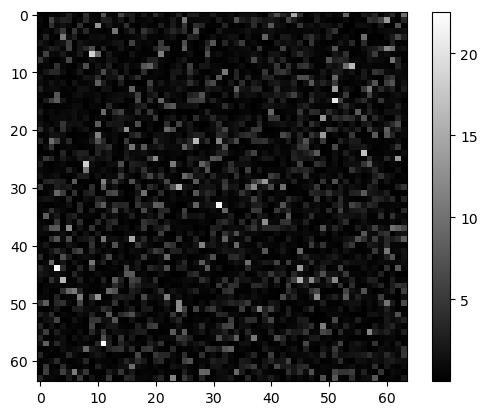

In [148]:
import matplotlib.pyplot as plt
plt.imshow(percent_mean_errors[0], cmap='gray')
plt.colorbar()

These graphs show there are some pixels with extremely high mean and standard deviation percent errors

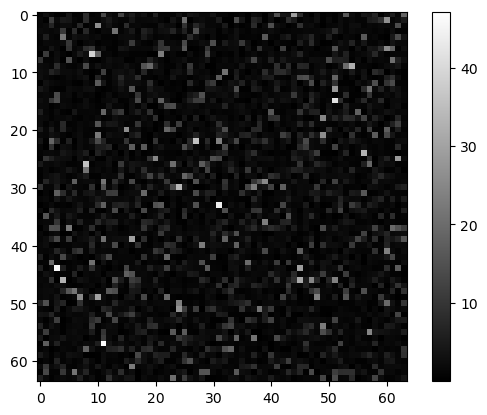

In [149]:
import matplotlib.pyplot as plt
plt.imshow(percent_std_errors[0], cmap='gray')
plt.colorbar()

In [43]:
b = volume[:, 32, 30]

In [44]:
b

array([8.74295859, 2.1355728 , 1.64167265, ..., 1.76390939, 1.63832854,
       1.09238732])

This was where I thought the wrong pixel was causing the high errors, this pixel actually has very low error even though the first value is an 8

In [65]:
percent_mean_errors[0][32][30]

0.42854344624960766

In [77]:
np.max(re_std)

43.94348779417757

In [95]:
x = 0
y = 0
max = 43.94348779417757
for i in range(64):
    for j in range(64):
        if(percent_std_errors[0][i][j] == max):
            x = i
            y = j
        

Found the pixel causing the high percent errors

In [98]:
percent_std_errors[0][33][31]

43.94348779417757

In [108]:
b = volume[:,33, 31]

In [102]:
true_std[33, 31]

1.0127833586626447

In [103]:
std[33, 31]

1.4578356902580256

This pixel has a percent error of around 43, below are its first ten values, don't know why this eight is causing so much more issues than the first

In [150]:
b[0:10]

array([-0.92488531,  2.35453874,  8.85390752,  0.21995705,  1.36063541,
        1.32870013,  0.89020438, -0.05338712,  1.68822875,  3.22463267])

In [123]:
#graphing average error vs buffer size
x = []
mean_errors = []
std_errors = []
for key, value in final.items():
    x.append(int(key))
    mean_errors.append(value[0])
    std_errors.append(value[1])

    

    

Text(0.5, 1.0, 'Mean Percent Error vs Buffer Size')

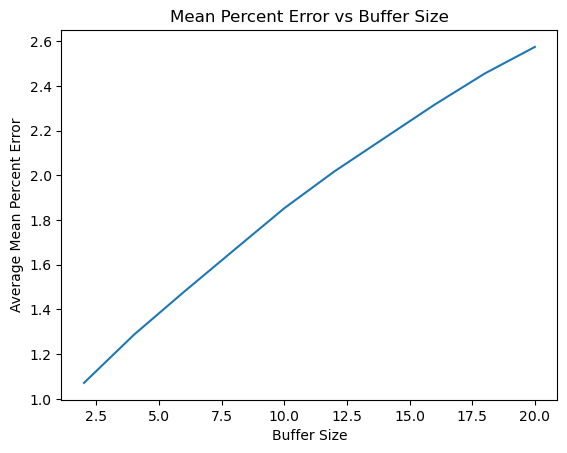

In [125]:
plt.plot(x, mean_errors)
plt.xlabel("Buffer Size")
plt.ylabel("Average Mean Percent Error")
plt.title("Mean Percent Error vs Buffer Size")

Text(0.5, 1.0, 'Standard Deviation Percent Error vs Buffer Size')

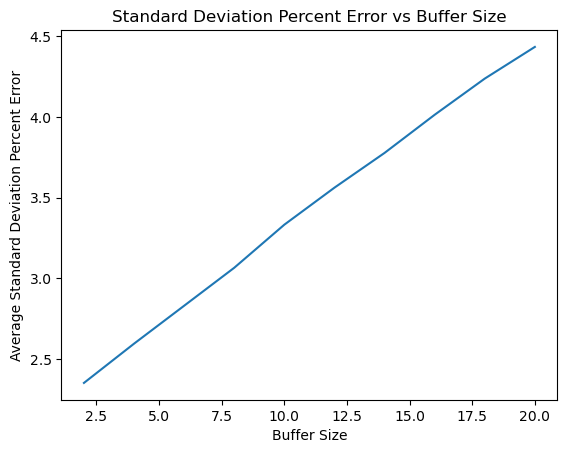

In [126]:
plt.plot(x, std_errors)
plt.xlabel("Buffer Size")
plt.ylabel("Average Standard Deviation Percent Error")
plt.title("Standard Deviation Percent Error vs Buffer Size")